# Stabilized accDM likelihood maps for direct DCDM comparison

This notebook is deliberately **plotting-only**. It reads the tabular products of the
updated hybrid accDM analysis and produces smooth figures in both native accDM and
effective DCDM coordinates.

The plotting convention is:

- the reference/global minimum is selected only in the stable window
  $-2.5\leq\log_{10}(\epsilon_{\rm eff})\leq-2.0$ and $f_{\rm acc}\leq0.1$;
- missing low-fraction cells are replaced by local neighbour averages;
- missing high-fraction cells are filled for visualization and q-sensitive points can be
  downweighted toward their local neighbourhood;
- the high-fraction surface is mildly smoothed and rebased because its absolute minimum
  is not yet numerically converged;
- the final figures contain no failure crosses, while the first quality-control figure
  retains the raw sampled points and all missing locations.

**Important:** the stabilized surface is a visual guide for comparison with the DCDM
notebook. It must not be used as a replacement for the final profile likelihood after
uniform refitting and q-convergence validation.


In [1]:
from pathlib import Path
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.ndimage import gaussian_filter


def find_project_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "lyalpha_pt").is_dir():
            return candidate
    # This fallback makes the notebook executable next to exported CSV files as well.
    return start


PROJECT_ROOT = find_project_root()
TRANSITION_LOGF = -1.0
STABLE_LOGEPS_WINDOW = (-2.5, -2.0)
DELTA_CHI2_68_2D = 2.30
DELTA_CHI2_95_2D = 5.991
EXCLUSION_DELTA_CHI2 = 3.841
DISPLAY_DELTA_MAX = 20.0
T_REFERENCE_GYR = 14.0

# Visual regularization controls. Sigma is measured in coarse grid-cell units (f, mass).
LOWF_GAUSSIAN_SIGMA = (0.28, 0.42)
HIGHF_GAUSSIAN_SIGMA = (0.70, 0.85)
USE_Q_STABILITY_REGULARIZATION = True
RAW_RMS_UNSTABLE = 0.003       # 0.3 per cent in fractional units
SHAPE_SHIFT_UNSTABLE = 3.0
UNSTABLE_POINT_ORIGINAL_WEIGHT = 0.25
HIGHF_MINIMUM_FLOOR = 0.25     # high-f visual floor above the stable reference
BRIDGE_RESOLUTION_TRANSITION = True

SAVE_OUTPUTS = os.environ.get("ACCDM_SAVE_OUTPUTS", "1").lower() not in {
    "0", "false", "no",
}

DEFAULT_ANALYSIS_DIR = (
    PROJECT_ROOT / "runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1"
)
INPUT_CANDIDATES = [
    DEFAULT_ANALYSIS_DIR,
    Path.cwd() / "upload",
    Path.cwd(),
]


def locate_input_directory():
    required = "updated_hybrid_sampled_profile_likelihood.csv"
    for candidate in INPUT_CANDIDATES:
        if (candidate / required).is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find updated_hybrid_sampled_profile_likelihood.csv in: "
        + ", ".join(str(path) for path in INPUT_CANDIDATES)
    )


INPUT_DIR = locate_input_directory()
if (PROJECT_ROOT / "runs").is_dir():
    OUTPUT_DIR = PROJECT_ROOT / "runs/accdm/analysis_stabilized_dcdm_comparison_v1"
else:
    OUTPUT_DIR = Path.cwd() / "stabilized_accdm_plots"

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input directory :", INPUT_DIR)
print("Output directory:", OUTPUT_DIR)
print("Stable log-epsilon window:", STABLE_LOGEPS_WINDOW)
print("Transition log10(f_acc):", TRANSITION_LOGF)


Input directory : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1
Output directory: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_stabilized_dcdm_comparison_v1
Stable log-epsilon window: (-2.5, -2.0)
Transition log10(f_acc): -1.0


## Load the plotting tables

The notebook uses the CSV products written by
`05_analyze_updated_hybrid_q1001_q5001_recovery.ipynb`. No CLASS or P1D fit is rerun.


In [2]:
sampled_path = INPUT_DIR / "updated_hybrid_sampled_profile_likelihood.csv"
missing_path = INPUT_DIR / "updated_hybrid_cross_markers.csv"
q_diagnostics_path = INPUT_DIR / "updated_raw_to_fit_overlap.csv"
summary_path = INPUT_DIR / "updated_hybrid_analysis_summary.json"

sampled = pd.read_csv(sampled_path)
missing = pd.read_csv(missing_path) if missing_path.is_file() else pd.DataFrame(
    columns=["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]
)
q_diagnostics = pd.read_csv(q_diagnostics_path) if q_diagnostics_path.is_file() else pd.DataFrame()

if summary_path.is_file():
    analysis_summary = json.loads(summary_path.read_text(encoding="utf-8"))
    LCDM_ONE_LOOP_CHI2 = float(analysis_summary["lcdm_reference_chi2"])
else:
    analysis_summary = {}
    LCDM_ONE_LOOP_CHI2 = 193.105787
    warnings.warn(f"Using fallback LCDM chi2={LCDM_ONE_LOOP_CHI2}.")

required_columns = {"log10m_acc", "log10f_acc", "chi2_one_loop"}
absent = required_columns - set(sampled.columns)
if absent:
    raise KeyError(f"Missing required sampled columns: {sorted(absent)}")

sampled = sampled.loc[np.isfinite(sampled["chi2_one_loop"])].copy()
if "expected_region" not in sampled:
    sampled["expected_region"] = np.where(
        sampled["log10f_acc"] <= TRANSITION_LOGF, "low", "high"
    )
if not missing.empty and "expected_region" not in missing:
    missing["expected_region"] = np.where(
        missing["log10f_acc"] <= TRANSITION_LOGF, "low", "high"
    )

print("Completed sampled points:", len(sampled))
print("Missing expected points  :", len(missing))
print("LCDM reference chi2      :", LCDM_ONE_LOOP_CHI2)


Completed sampled points: 1425
Missing expected points  : 25
LCDM reference chi2      : 193.19661059914853


## Effective coordinates and the stable reference minimum

The mapping is the same as in the updated hybrid notebook. It is useful for visual
comparison, but it is not an exact physical equivalence between accDM and DCDM.


In [3]:
def eta_from_log10_mass(log10m_acc):
    return 10.0 ** (11.0 - np.asarray(log10m_acc, dtype=float))


def epsilon_effective_from_log10_mass(log10m_acc):
    eta = eta_from_log10_mass(log10m_acc)
    recoil = np.sqrt(eta * (eta + 2.0))
    return recoil / (np.sqrt(1.0 + recoil**2) + recoil)


def gamma_effective_from_log10_fraction(log10f_acc, t_reference_gyr=T_REFERENCE_GYR):
    fraction = 10.0 ** np.asarray(log10f_acc, dtype=float)
    gamma = np.full_like(fraction, np.inf, dtype=float)
    finite = fraction < 1.0
    gamma[finite] = -np.log1p(-fraction[finite]) / float(t_reference_gyr)
    return gamma


sampled["log10_epsilon_eff"] = np.log10(
    epsilon_effective_from_log10_mass(sampled["log10m_acc"])
)
sampled["log10_gamma_eff"] = np.log10(
    gamma_effective_from_log10_fraction(sampled["log10f_acc"])
)

stable_candidates = sampled.loc[
    sampled["log10_epsilon_eff"].between(*STABLE_LOGEPS_WINDOW)
    & (sampled["log10f_acc"] <= TRANSITION_LOGF + 1e-12)
].copy()
if stable_candidates.empty:
    raise RuntimeError("No completed low-f point lies in the stable epsilon window.")

stable_reference = stable_candidates.loc[stable_candidates["chi2_one_loop"].idxmin()]
raw_numerical_minimum = sampled.loc[sampled["chi2_one_loop"].idxmin()]
REFERENCE_CHI2 = float(stable_reference["chi2_one_loop"])

print("Stable reference minimum")
print("  point_id        =", stable_reference.get("point_id", "n/a"))
print(f"  log10(m/GeV)    = {stable_reference['log10m_acc']:.6f}")
print(f"  log10(f_acc)    = {stable_reference['log10f_acc']:.6f}")
print(f"  log10(eps_eff)  = {stable_reference['log10_epsilon_eff']:.6f}")
print(f"  chi2            = {REFERENCE_CHI2:.9f}")
print(f"  Delta chi2 LCDM = {REFERENCE_CHI2 - LCDM_ONE_LOOP_CHI2:+.9f}")
print("\nRaw numerical minimum, shown only in the control figure")
print("  point_id        =", raw_numerical_minimum.get("point_id", "n/a"))
print(f"  log10(m/GeV)    = {raw_numerical_minimum['log10m_acc']:.6f}")
print(f"  log10(f_acc)    = {raw_numerical_minimum['log10f_acc']:.6f}")
print(f"  chi2            = {raw_numerical_minimum['chi2_one_loop']:.9f}")


Stable reference minimum
  point_id        = accdm_logm15p7142857142857_logfm1p3
  log10(m/GeV)    = 15.714286
  log10(f_acc)    = -1.300000
  log10(eps_eff)  = -2.209324
  chi2            = 188.986412635
  Delta chi2 LCDM = -4.210197964

Raw numerical minimum, shown only in the control figure
  point_id        = accdm_logm12p7142857142857_logfm0p2
  log10(m/GeV)    = 12.714286
  log10(f_acc)    = -0.200000
  chi2            = 188.429597466


## Fill missing cells by neighbour averages

Low- and high-fraction regions are processed separately, so values are never averaged
through the $f_{\rm acc}=0.1$ resolution boundary. Missing cells are first filled by the
mean of their nearest finite neighbours along the grid axes. A linear/nearest fallback is
used only if an extended missing block cannot be reached iteratively.


In [4]:
expected_points = pd.concat([
    sampled[["log10m_acc", "log10f_acc", "expected_region"]],
    missing[["log10m_acc", "log10f_acc", "expected_region"]],
], ignore_index=True).drop_duplicates(["log10m_acc", "log10f_acc"])

x_grid = np.sort(expected_points["log10m_acc"].unique())
y_grid = np.sort(expected_points["log10f_acc"].unique())
chi_table = sampled.pivot_table(
    index="log10f_acc", columns="log10m_acc", values="chi2_one_loop", aggfunc="last"
).reindex(index=y_grid, columns=x_grid)
chi_raw_grid = chi_table.to_numpy(dtype=float)


def nearest_axis_values(array, i, j, row_mask):
    values = []
    # Horizontal neighbours in the same fraction row.
    for direction in (-1, 1):
        jj = j + direction
        while 0 <= jj < array.shape[1]:
            if np.isfinite(array[i, jj]):
                values.append(float(array[i, jj]))
                break
            jj += direction
    # Vertical neighbours, restricted to the same resolution region.
    for direction in (-1, 1):
        ii = i + direction
        while 0 <= ii < array.shape[0] and row_mask[ii]:
            if np.isfinite(array[ii, j]):
                values.append(float(array[ii, j]))
                break
            ii += direction
    return values


def fill_region_by_neighbour_average(array, row_mask, max_iterations=50):
    filled = np.array(array, dtype=float, copy=True)
    initially_missing = row_mask[:, None] & ~np.isfinite(filled)
    provenance = np.zeros_like(filled, dtype=bool)
    for _ in range(max_iterations):
        updates = []
        for i, j in np.argwhere(row_mask[:, None] & ~np.isfinite(filled)):
            neighbours = nearest_axis_values(filled, int(i), int(j), row_mask)
            if len(neighbours) >= 2:
                updates.append((int(i), int(j), float(np.mean(neighbours))))
        if not updates:
            break
        for i, j, value in updates:
            filled[i, j] = value
            provenance[i, j] = True

    remaining = row_mask[:, None] & ~np.isfinite(filled)
    if np.any(remaining):
        yy, xx = np.meshgrid(y_grid, x_grid, indexing="ij")
        known = row_mask[:, None] & np.isfinite(filled)
        target = np.column_stack([yy[remaining], xx[remaining]])
        linear = griddata(
            np.column_stack([yy[known], xx[known]]), filled[known], target,
            method="linear",
        )
        nearest = griddata(
            np.column_stack([yy[known], xx[known]]), filled[known], target,
            method="nearest",
        )
        replacement = np.where(np.isfinite(linear), linear, nearest)
        filled[remaining] = replacement
        provenance[remaining] = True
    return filled, initially_missing, provenance


low_rows = y_grid <= TRANSITION_LOGF + 1e-12
high_rows = y_grid > TRANSITION_LOGF + 1e-12
chi_filled = np.array(chi_raw_grid, copy=True)

low_filled, low_missing_mask, low_provenance = fill_region_by_neighbour_average(
    chi_filled, low_rows,
)
chi_filled[low_rows] = low_filled[low_rows]
high_filled, high_missing_mask, high_provenance = fill_region_by_neighbour_average(
    chi_filled, high_rows,
)
chi_filled[high_rows] = high_filled[high_rows]

print("Filled low-f cells :", int(low_provenance.sum()))
print("Filled high-f cells:", int(high_provenance.sum()))
if not np.isfinite(chi_filled[low_rows | high_rows]).all():
    raise RuntimeError("Some expected grid cells remain unfilled.")


Filled low-f cells : 0
Filled high-f cells: 25


## Construct the stabilized visual surface

q-sensitive high-fraction points are blended toward the median of their local 3x3
neighbourhood. A mild Gaussian filter is then applied separately below and above the
resolution transition. Finally, the high-fraction surface is shifted as a whole when
necessary so that the selected stable low-fraction point remains the presentation
minimum. This last offset reflects the fact that the absolute normalization of the
unresolved high-fraction likelihood is not yet trusted.


In [5]:
chi_regularized = np.array(chi_filled, copy=True)
unstable_coordinates = set()

if USE_Q_STABILITY_REGULARIZATION and not q_diagnostics.empty:
    diagnostics = q_diagnostics.copy()
    diagnostics["q_unstable"] = (
        diagnostics["raw_rms_max"].abs() > RAW_RMS_UNSTABLE
    ) | (
        diagnostics["absolute_shape_shift"].abs() > SHAPE_SHIFT_UNSTABLE
    )
    for row in diagnostics.loc[diagnostics["q_unstable"]].itertuples():
        i = int(np.argmin(np.abs(y_grid - float(row.log10f_acc))))
        j = int(np.argmin(np.abs(x_grid - float(row.log10m_acc))))
        if not high_rows[i]:
            continue
        unstable_coordinates.add((i, j))

    source = np.array(chi_filled, copy=True)
    for i, j in sorted(unstable_coordinates):
        i0, i1 = max(0, i - 1), min(source.shape[0], i + 2)
        j0, j1 = max(0, j - 1), min(source.shape[1], j + 2)
        neighbours = source[i0:i1, j0:j1].copy().ravel()
        centre_index = (i - i0) * (j1 - j0) + (j - j0)
        neighbours = np.delete(neighbours, centre_index)
        neighbours = neighbours[np.isfinite(neighbours)]
        if neighbours.size >= 3:
            local_target = float(np.median(neighbours))
            chi_regularized[i, j] = (
                UNSTABLE_POINT_ORIGINAL_WEIGHT * source[i, j]
                + (1.0 - UNSTABLE_POINT_ORIGINAL_WEIGHT) * local_target
            )


def smooth_selected_rows(array, row_mask, sigma):
    output = np.array(array, copy=True)
    indices = np.flatnonzero(row_mask)
    if indices.size:
        output[indices, :] = gaussian_filter(
            array[indices, :], sigma=sigma, mode="nearest"
        )
    return output


chi_smoothed = smooth_selected_rows(
    chi_regularized, low_rows, LOWF_GAUSSIAN_SIGMA,
)
chi_smoothed = smooth_selected_rows(
    chi_smoothed, high_rows, HIGHF_GAUSSIAN_SIGMA,
)

ref_i = int(np.argmin(np.abs(y_grid - float(stable_reference["log10f_acc"]))))
ref_j = int(np.argmin(np.abs(x_grid - float(stable_reference["log10m_acc"]))))
delta_visual_grid = chi_smoothed - chi_smoothed[ref_i, ref_j]
delta_visual_grid[ref_i, ref_j] = 0.0

high_min_before_rebase = float(np.nanmin(delta_visual_grid[high_rows]))
highf_offset = max(0.0, HIGHF_MINIMUM_FLOOR - high_min_before_rebase)
delta_visual_grid[high_rows] += highf_offset
delta_visual_grid = np.maximum(delta_visual_grid, 0.0)
delta_visual_grid[ref_i, ref_j] = 0.0

visual_chi2_grid = REFERENCE_CHI2 + delta_visual_grid
delta_lcdm_visual_grid = visual_chi2_grid - LCDM_ONE_LOOP_CHI2

print("q-sensitive high-f cells blended:", len(unstable_coordinates))
print(f"High-f minimum before rebase: {high_min_before_rebase:+.6f}")
print(f"Applied high-f visual offset: {highf_offset:+.6f}")
print("Stable reference remains at Delta chi2 =", delta_visual_grid[ref_i, ref_j])


q-sensitive high-f cells blended: 298
High-f minimum before rebase: +0.930714
Applied high-f visual offset: +0.000000
Stable reference remains at Delta chi2 = 0.0


## Dense surfaces and the raw-versus-stabilized control figure

Only this control figure shows the missing cells and the original numerical minimum.
The final presentation figures below contain the neighbour-filled stabilized surface.


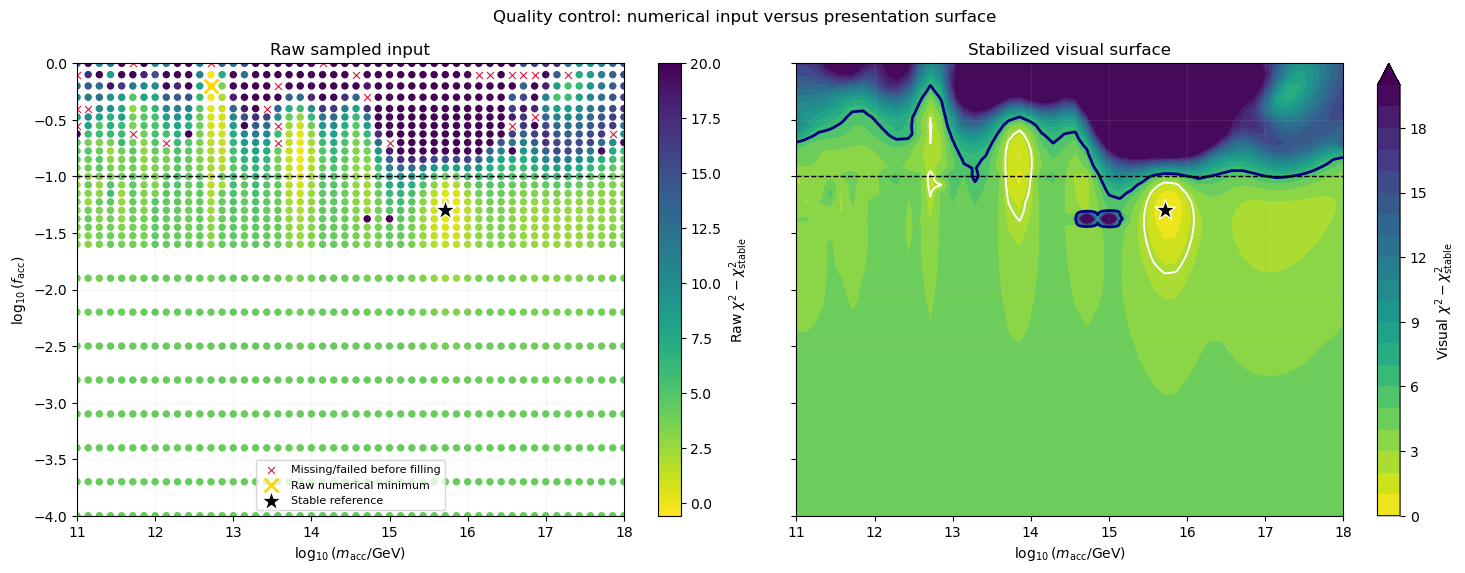

In [6]:
def dense_surface(values, nx=720, ny=580):
    x_dense = np.linspace(x_grid.min(), x_grid.max(), nx)
    y_dense = np.linspace(y_grid.min(), y_grid.max(), ny)
    xx, yy = np.meshgrid(x_dense, y_dense)
    if BRIDGE_RESOLUTION_TRANSITION:
        # The coarse low/high regions were already filled and smoothed separately.
        # This final linear interpolation only closes the narrow plotting gap between
        # the last low-f row and the first high-f row.
        interpolator = RegularGridInterpolator(
            (y_grid, x_grid), values,
            method="linear", bounds_error=False, fill_value=np.nan,
        )
        dense = interpolator(
            np.column_stack([yy.ravel(), xx.ravel()])
        ).reshape(xx.shape)
        return x_dense, y_dense, dense
    dense = np.full_like(xx, np.nan, dtype=float)
    for row_mask, dense_mask in [
        (low_rows, yy <= TRANSITION_LOGF + 1e-12),
        (high_rows, yy > TRANSITION_LOGF + 1e-12),
    ]:
        interpolator = RegularGridInterpolator(
            (y_grid[row_mask], x_grid), values[row_mask, :],
            method="linear", bounds_error=False, fill_value=np.nan,
        )
        evaluated = interpolator(
            np.column_stack([yy.ravel(), xx.ravel()])
        ).reshape(xx.shape)
        dense[dense_mask] = evaluated[dense_mask]
    return x_dense, y_dense, dense


x_dense, y_dense, delta_visual_dense = dense_surface(delta_visual_grid)
_, _, delta_lcdm_visual_dense = dense_surface(delta_lcdm_visual_grid)

sampled["delta_chi2_from_stable_reference"] = (
    sampled["chi2_one_loop"] - REFERENCE_CHI2
)
fig_control, axes = plt.subplots(1, 2, figsize=(15.0, 5.8), sharex=True, sharey=True)

raw_scatter = axes[0].scatter(
    sampled["log10m_acc"], sampled["log10f_acc"],
    c=np.clip(sampled["delta_chi2_from_stable_reference"], -2, DISPLAY_DELTA_MAX),
    cmap="viridis_r", s=29, edgecolor="none", rasterized=True,
)
axes[0].scatter(
    missing["log10m_acc"], missing["log10f_acc"], marker="x", s=25,
    color="crimson", linewidth=0.8, label="Missing/failed before filling",
)
axes[0].scatter(
    [raw_numerical_minimum["log10m_acc"]], [raw_numerical_minimum["log10f_acc"]],
    marker="x", s=100, color="gold", linewidth=2.0, label="Raw numerical minimum",
)
axes[0].scatter(
    [stable_reference["log10m_acc"]], [stable_reference["log10f_acc"]],
    marker="*", s=240, color="black", edgecolor="white", label="Stable reference",
)
axes[0].set_title("Raw sampled input")
axes[0].legend(frameon=True, fontsize=8)
fig_control.colorbar(raw_scatter, ax=axes[0], label=r"Raw $\chi^2-\chi^2_{\rm stable}$")

stabilized = axes[1].contourf(
    x_dense, y_dense, np.clip(delta_visual_dense, 0, DISPLAY_DELTA_MAX),
    levels=np.linspace(0, DISPLAY_DELTA_MAX, 21), cmap="viridis_r", extend="max",
)
axes[1].contour(
    x_dense, y_dense, delta_visual_dense,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
    colors=["white", "navy"], linewidths=[1.4, 2.0],
)
axes[1].scatter(
    [stable_reference["log10m_acc"]], [stable_reference["log10f_acc"]],
    marker="*", s=240, color="black", edgecolor="white",
)
axes[1].set_title("Stabilized visual surface")
fig_control.colorbar(stabilized, ax=axes[1], label=r"Visual $\chi^2-\chi^2_{\rm stable}$")

for axis in axes:
    axis.axhline(TRANSITION_LOGF, color="black", ls="--", lw=1.0)
    axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
    axis.grid(alpha=0.12)
axes[0].set_ylabel(r"$\log_{10}(f_{\rm acc})$")
fig_control.suptitle("Quality control: numerical input versus presentation surface")
fig_control.tight_layout()
plt.show()


## Final native accDM profile-likelihood map


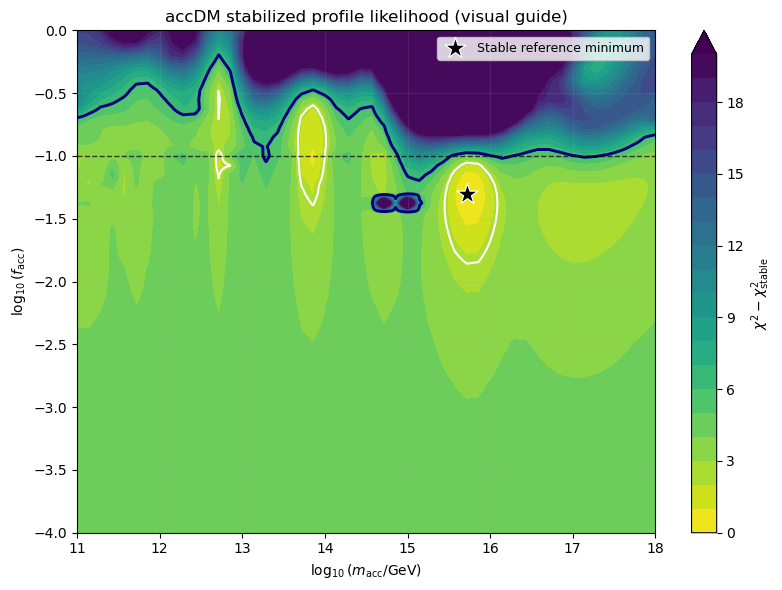

In [7]:
fig_native, axis = plt.subplots(figsize=(8.2, 6.0))
native_plot = axis.contourf(
    x_dense, y_dense, np.clip(delta_visual_dense, 0, DISPLAY_DELTA_MAX),
    levels=np.linspace(0, DISPLAY_DELTA_MAX, 21), cmap="viridis_r", extend="max",
)
axis.contour(
    x_dense, y_dense, delta_visual_dense,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
    colors=["white", "navy"], linewidths=[1.5, 2.1],
)
axis.scatter(
    [stable_reference["log10m_acc"]], [stable_reference["log10f_acc"]],
    marker="*", s=250, color="black", edgecolor="white", linewidth=0.9,
    label="Stable reference minimum", zorder=6,
)
axis.axhline(TRANSITION_LOGF, color="black", ls="--", lw=1.0, alpha=0.7)
axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
axis.set_ylabel(r"$\log_{10}(f_{\rm acc})$")
axis.set_title("accDM stabilized profile likelihood (visual guide)")
axis.legend(frameon=True, fontsize=9)
axis.grid(alpha=0.12)
fig_native.colorbar(native_plot, ax=axis, label=r"$\chi^2-\chi^2_{\rm stable}$")
fig_native.tight_layout()
plt.show()


## Final map in effective DCDM coordinates

This uses the same axes and 68%/95% contour convention as the DCDM campaign notebook.


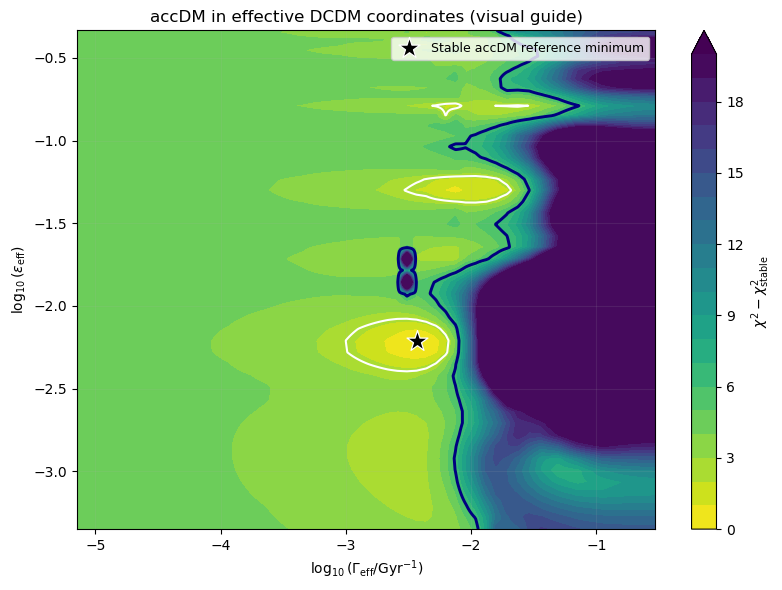

In [8]:
epsilon_dense = epsilon_effective_from_log10_mass(x_dense)
gamma_dense = gamma_effective_from_log10_fraction(y_dense)
finite_gamma_rows = np.isfinite(gamma_dense) & (gamma_dense > 0)
log_gamma_dense = np.log10(gamma_dense[finite_gamma_rows])
log_epsilon_dense = np.log10(epsilon_dense[::-1])


def dcdm_orientation(surface):
    return np.asarray(surface)[finite_gamma_rows, ::-1].T


delta_effective = dcdm_orientation(delta_visual_dense)
delta_lcdm_effective = dcdm_orientation(delta_lcdm_visual_dense)
stable_gamma = float(stable_reference["log10_gamma_eff"])
stable_epsilon = float(stable_reference["log10_epsilon_eff"])

fig_effective, axis = plt.subplots(figsize=(8.2, 6.0))
effective_plot = axis.contourf(
    log_gamma_dense, log_epsilon_dense,
    np.clip(delta_effective, 0, DISPLAY_DELTA_MAX),
    levels=np.linspace(0, DISPLAY_DELTA_MAX, 21), cmap="viridis_r", extend="max",
)
axis.contour(
    log_gamma_dense, log_epsilon_dense, delta_effective,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
    colors=["white", "navy"], linewidths=[1.5, 2.1],
)
axis.scatter(
    [stable_gamma], [stable_epsilon], marker="*", s=250,
    color="black", edgecolor="white", linewidth=0.9,
    label="Stable accDM reference minimum", zorder=6,
)
axis.set_xlabel(r"$\log_{10}(\Gamma_{\rm eff}/{\rm Gyr}^{-1})$")
axis.set_ylabel(r"$\log_{10}(\epsilon_{\rm eff})$")
axis.set_title("accDM in effective DCDM coordinates (visual guide)")
axis.legend(frameon=True, fontsize=9)
axis.grid(alpha=0.12)
fig_effective.colorbar(
    effective_plot, ax=axis, label=r"$\chi^2-\chi^2_{\rm stable}$"
)
fig_effective.tight_layout()
plt.show()


## DCDM-notebook-style two-panel figure

The left panel shows the 95% region relative to the selected stable accDM reference. The
right panel follows the DCDM notebook convention for the difference relative to LCDM.


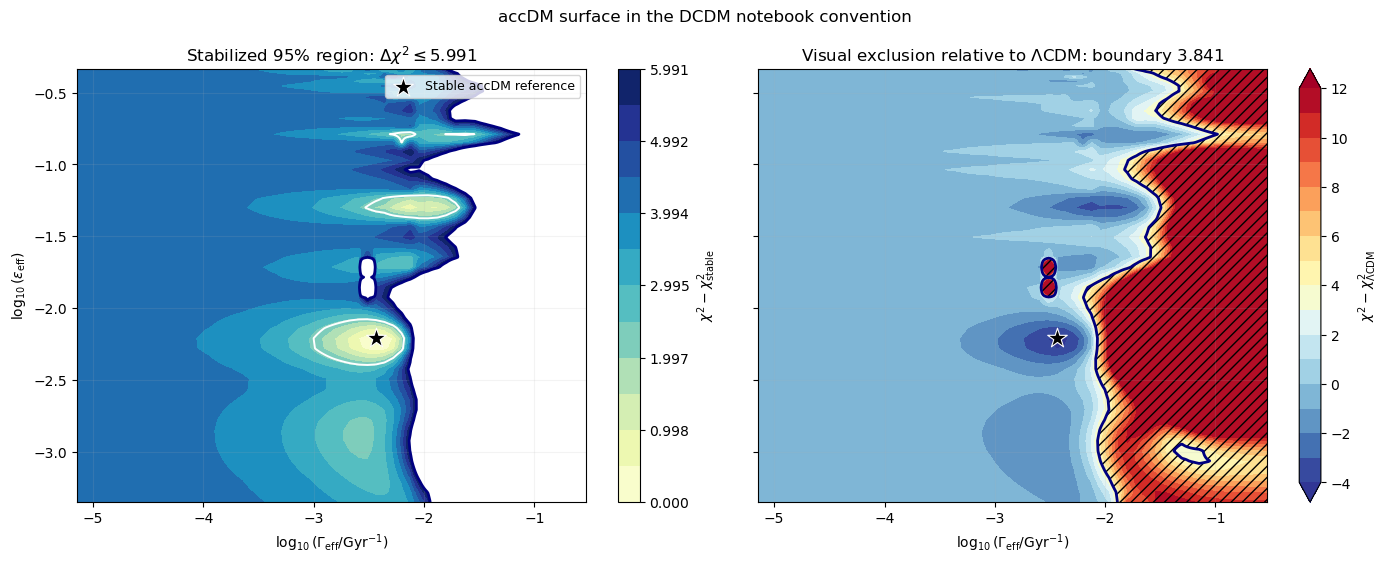

In [9]:
fig_paper, axes = plt.subplots(1, 2, figsize=(14.2, 5.7), sharex=True, sharey=True)

allowed_display = np.ma.masked_where(
    delta_effective > DELTA_CHI2_95_2D, delta_effective
)
allowed_plot = axes[0].contourf(
    log_gamma_dense, log_epsilon_dense, allowed_display,
    levels=np.linspace(0, DELTA_CHI2_95_2D, 13), cmap="YlGnBu",
)
axes[0].contour(
    log_gamma_dense, log_epsilon_dense, delta_effective,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
    colors=["white", "navy"], linewidths=[1.4, 2.0],
)
axes[0].set_title(r"Stabilized 95% region: $\Delta\chi^2\leq5.991$")
fig_paper.colorbar(allowed_plot, ax=axes[0], label=r"$\chi^2-\chi^2_{\rm stable}$")

lcdm_plot = axes[1].contourf(
    log_gamma_dense, log_epsilon_dense,
    np.clip(delta_lcdm_effective, -4, 12),
    levels=np.linspace(-4, 12, 17), cmap="RdYlBu_r", extend="both",
)
axes[1].contour(
    log_gamma_dense, log_epsilon_dense, delta_lcdm_effective,
    levels=[EXCLUSION_DELTA_CHI2], colors="navy", linewidths=2.0,
)
axes[1].contourf(
    log_gamma_dense, log_epsilon_dense, delta_lcdm_effective,
    levels=[EXCLUSION_DELTA_CHI2, np.nanmax(delta_lcdm_effective) + 1],
    colors="none", hatches=["///"],
)
axes[1].set_title(r"Visual exclusion relative to $\Lambda$CDM: boundary 3.841")
fig_paper.colorbar(lcdm_plot, ax=axes[1], label=r"$\chi^2-\chi^2_{\Lambda\mathrm{CDM}}$")

for axis in axes:
    axis.scatter(
        [stable_gamma], [stable_epsilon], marker="*", s=220,
        color="black", edgecolor="white", linewidth=0.8,
        label="Stable accDM reference", zorder=6,
    )
    axis.set_xlabel(r"$\log_{10}(\Gamma_{\rm eff}/{\rm Gyr}^{-1})$")
    axis.grid(alpha=0.14)
axes[0].set_ylabel(r"$\log_{10}(\epsilon_{\rm eff})$")
axes[0].legend(frameon=True, fontsize=9, loc="best")
fig_paper.suptitle("accDM surface in the DCDM notebook convention")
fig_paper.tight_layout()
plt.show()


## Optional direct side-by-side comparison with the DCDM output

This cell runs when the DCDM notebook has already written
`runs/dcdm/dcdm_paper_grid_v1/analysis/campaign_profile_likelihood.csv`.


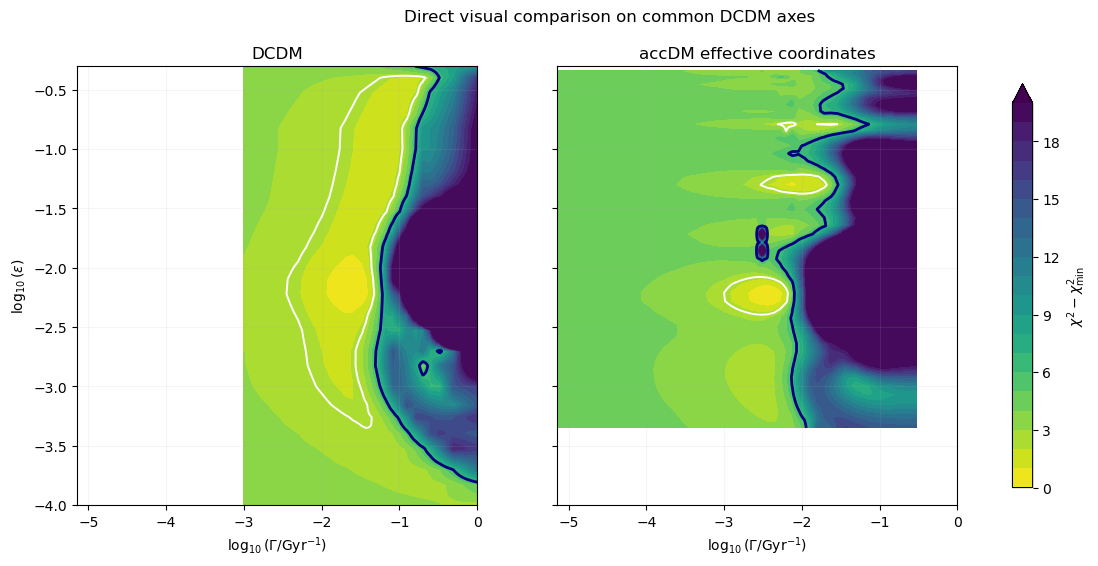

In [10]:
DCDM_PROFILE_CSV = (
    PROJECT_ROOT / "runs/dcdm/dcdm_paper_grid_v1/analysis/campaign_profile_likelihood.csv"
)
fig_direct_comparison = None

if DCDM_PROFILE_CSV.is_file():
    dcdm = pd.read_csv(DCDM_PROFILE_CSV)
    dcdm = dcdm.loc[np.isfinite(dcdm["chi2_one_loop"])].copy()
    if "delta_chi2_from_grid_minimum" not in dcdm:
        dcdm["delta_chi2_from_grid_minimum"] = (
            dcdm["chi2_one_loop"] - dcdm["chi2_one_loop"].min()
        )
    dx = np.sort(dcdm["log10_gamma_gyr_inverse"].unique())
    dy = np.sort(dcdm["log10_epsilon"].unique())
    dgrid = dcdm.pivot_table(
        index="log10_epsilon", columns="log10_gamma_gyr_inverse",
        values="delta_chi2_from_grid_minimum", aggfunc="last",
    ).reindex(index=dy, columns=dx).to_numpy(dtype=float)
    dxx = np.linspace(dx.min(), dx.max(), 600)
    dyy = np.linspace(dy.min(), dy.max(), 500)
    dmx, dmy = np.meshgrid(dxx, dyy)
    dinterp = RegularGridInterpolator(
        (dy, dx), dgrid, method="linear", bounds_error=False, fill_value=np.nan,
    )
    ddense = dinterp(np.column_stack([dmy.ravel(), dmx.ravel()])).reshape(dmx.shape)

    fig_direct_comparison, axes = plt.subplots(
        1, 2, figsize=(14.2, 5.7), sharex=True, sharey=True,
    )
    for axis, xx, yy, surface, title in [
        (axes[0], dxx, dyy, ddense, "DCDM"),
        (axes[1], log_gamma_dense, log_epsilon_dense, delta_effective,
         "accDM effective coordinates"),
    ]:
        plotted = axis.contourf(
            xx, yy, np.clip(surface, 0, DISPLAY_DELTA_MAX),
            levels=np.linspace(0, DISPLAY_DELTA_MAX, 21),
            cmap="viridis_r", extend="max",
        )
        axis.contour(
            xx, yy, surface, levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
            colors=["white", "navy"], linewidths=[1.4, 2.0],
        )
        axis.set_title(title)
        axis.set_xlabel(r"$\log_{10}(\Gamma/{\rm Gyr}^{-1})$")
        axis.grid(alpha=0.12)
    axes[0].set_ylabel(r"$\log_{10}(\epsilon)$")
    fig_direct_comparison.colorbar(
        plotted, ax=axes, label=r"$\chi^2-\chi^2_{\min}$", shrink=0.92,
    )
    fig_direct_comparison.suptitle("Direct visual comparison on common DCDM axes")
    plt.show()
else:
    print("DCDM profile CSV not found; optional side-by-side figure skipped:")
    print(" ", DCDM_PROFILE_CSV)


## Save presentation figures and an auditable visual grid

The CSV and JSON record every fill and regularization choice, so the presentation surface
can always be distinguished from the original fitted likelihood.


In [11]:
visual_rows = []
for i, logf in enumerate(y_grid):
    for j, logm in enumerate(x_grid):
        visual_rows.append({
            "log10m_acc": float(logm),
            "log10f_acc": float(logf),
            "region": "low" if low_rows[i] else "high",
            "chi2_raw": float(chi_raw_grid[i, j]) if np.isfinite(chi_raw_grid[i, j]) else np.nan,
            "chi2_filled": float(chi_filled[i, j]),
            "chi2_regularized": float(chi_regularized[i, j]),
            "delta_chi2_visual": float(delta_visual_grid[i, j]),
            "filled_from_neighbours": bool(low_provenance[i, j] or high_provenance[i, j]),
            "q_sensitive_blended": bool((i, j) in unstable_coordinates),
        })
visual_grid = pd.DataFrame(visual_rows)

metadata = {
    "purpose": "visual comparison with DCDM; not final statistical inference",
    "input_directory": str(INPUT_DIR),
    "stable_reference": {
        "point_id": str(stable_reference.get("point_id", "n/a")),
        "log10m_acc": float(stable_reference["log10m_acc"]),
        "log10f_acc": float(stable_reference["log10f_acc"]),
        "log10_epsilon_eff": float(stable_reference["log10_epsilon_eff"]),
        "log10_gamma_eff": float(stable_reference["log10_gamma_eff"]),
        "chi2": REFERENCE_CHI2,
    },
    "stable_logepsilon_window": list(STABLE_LOGEPS_WINDOW),
    "transition_log10f": TRANSITION_LOGF,
    "lowf_gaussian_sigma_grid_cells": list(LOWF_GAUSSIAN_SIGMA),
    "highf_gaussian_sigma_grid_cells": list(HIGHF_GAUSSIAN_SIGMA),
    "raw_rms_unstable_threshold": RAW_RMS_UNSTABLE,
    "shape_shift_unstable_threshold": SHAPE_SHIFT_UNSTABLE,
    "unstable_point_original_weight": UNSTABLE_POINT_ORIGINAL_WEIGHT,
    "highf_minimum_floor": HIGHF_MINIMUM_FLOOR,
    "bridge_resolution_transition_for_plotting": BRIDGE_RESOLUTION_TRANSITION,
    "highf_applied_offset": float(highf_offset),
    "filled_lowf_cells": int(low_provenance.sum()),
    "filled_highf_cells": int(high_provenance.sum()),
    "q_sensitive_blended_cells": int(len(unstable_coordinates)),
}

if SAVE_OUTPUTS:
    visual_grid.to_csv(OUTPUT_DIR / "stabilized_visual_grid.csv", index=False)
    (OUTPUT_DIR / "stabilized_visualization_metadata.json").write_text(
        json.dumps(metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8",
    )
    fig_control.savefig(
        OUTPUT_DIR / "accdm_raw_vs_stabilized_control.png", dpi=220, bbox_inches="tight",
    )
    fig_native.savefig(
        OUTPUT_DIR / "accdm_stabilized_profile_native.png", dpi=220, bbox_inches="tight",
    )
    fig_effective.savefig(
        OUTPUT_DIR / "accdm_stabilized_profile_effective_dcdm.png",
        dpi=220, bbox_inches="tight",
    )
    fig_paper.savefig(
        OUTPUT_DIR / "accdm_dcdm_notebook_style.png", dpi=220, bbox_inches="tight",
    )
    if fig_direct_comparison is not None:
        fig_direct_comparison.savefig(
            OUTPUT_DIR / "dcdm_accdm_direct_visual_comparison.png",
            dpi=220, bbox_inches="tight",
        )
    print("Saved presentation products to:", OUTPUT_DIR)

display(pd.Series(metadata, name="value").to_frame())


Saved presentation products to: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_stabilized_dcdm_comparison_v1


,value
purpose,visual comparison with DCDM; not final statist...
input_directory,/home/2/ks405818/Master/lyalpha_one_loop/runs/...
stable_reference,{'point_id': 'accdm_logm15p7142857142857_logfm...
stable_logepsilon_window,"[-2.5, -2.0]"
transition_log10f,-1.0
lowf_gaussian_sigma_grid_cells,"[0.28, 0.42]"
highf_gaussian_sigma_grid_cells,"[0.7, 0.85]"
raw_rms_unstable_threshold,0.003
shape_shift_unstable_threshold,3.0
unstable_point_original_weight,0.25
